# Training vs Generated Data Analysis

Compares aggregate statistics, distributions and temporal structure between:
- **Reference**: the first `TRAINING_DATASET_SIZE` CSVs from the training directory (sorted)
- **Generated**: all CSVs produced by the reverse-diffusion model

Both datasets are log-price paths (`log_adj_close`).  
Reference paths may be full-length stock histories; generated paths are fixed-length windows.

In [1]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
REF_DIRECTORY         = "../data/replication_prices_window"          # training data folder
GEN_DIRECTORY         = "../data/generated/replication/NO_NO_REPL_PRIC_WIN_UNCO_ep-3000_sde-vp_noise-linear_lr-1e-04_NOAN_seq-64_stride-64_20260412"  # generated data folder
SEED                  = 42
TRAINING_SEED         = 42    # must match config["train"]["seed"] used during training
VAL_SPLIT_RATIO       = None  # set to e.g. 0.1 if --val_split_ratio was used; else None
TRAINING_DATASET_SIZE = 256   # number of sliding windows — mirrors --train_subset_size
                               # set to None to use all available (post-val) windows
SEQ_LEN               = 2048  # window length used during training (--seq_len)
STRIDE                = 400   # stride used during training (--stride)
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf as sm_acf

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"REF_DIRECTORY         : {REF_DIRECTORY}")
print(f"GEN_DIRECTORY         : {GEN_DIRECTORY}")
print(f"SEED                  : {SEED}")
print(f"TRAINING_DATASET_SIZE : {TRAINING_DATASET_SIZE}")
print(f"SEQ_LEN               : {SEQ_LEN}")
print(f"STRIDE                : {STRIDE}")

REF_DIRECTORY         : ../data/replication_prices_window
GEN_DIRECTORY         : ../data/generated/replication/NO_NO_REPL_PRIC_WIN_UNCO_ep-3000_sde-vp_noise-linear_lr-1e-04_NOAN_seq-64_stride-64_20260412
SEED                  : 42
TRAINING_DATASET_SIZE : 256
SEQ_LEN               : 2048
STRIDE                : 400


## 1. Load data

In [3]:
# ── Reference data ────────────────────────────────────────────────────────────
# Mirrors csdi_train_modified.py exactly:
#   1. Load ALL sorted CSVs — no file cap
#   2. Extract sliding windows with same SEQ_LEN / STRIDE / drop_incomplete=True
#   3. Replicate torch.randperm(seed) + val split + train_subset_size
import torch

ref_csv_files = sorted(Path(REF_DIRECTORY).glob("*.csv"))
if len(ref_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {REF_DIRECTORY}")

all_windows: list[np.ndarray] = []
n_skipped_short = 0
for fp in ref_csv_files:
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    T = len(series)
    max_start = T - SEQ_LEN
    if max_start < 0:   # shorter than SEQ_LEN — skip (drop_incomplete=True)
        n_skipped_short += 1
        continue
    for s in range(0, max_start + 1, STRIDE):
        all_windows.append(series[s : s + SEQ_LEN])

if n_skipped_short:
    print(f"[WARNING] {n_skipped_short} file(s) shorter than SEQ_LEN={SEQ_LEN} were skipped.")
if len(all_windows) == 0:
    raise RuntimeError("No windows could be extracted. Check SEQ_LEN / STRIDE / REF_DIRECTORY.")

print(f"Total windows in full dataset : {len(all_windows)} "
      f"(from {len(ref_csv_files) - n_skipped_short} usable file(s), "
      f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE})")

# ── Replicate training subset selection with torch RNG ────────────────────────
torch_rng  = torch.Generator().manual_seed(TRAINING_SEED)
all_indices = torch.randperm(len(all_windows), generator=torch_rng).tolist()

# Carve out val split first (mirrors val_split_ratio logic in training script)
if VAL_SPLIT_RATIO is not None:
    val_size   = max(1, int(len(all_windows) * VAL_SPLIT_RATIO))
    train_pool = all_indices[val_size:]
    print(f"Val split : {val_size} windows held out (VAL_SPLIT_RATIO={VAL_SPLIT_RATIO})")
else:
    train_pool = all_indices

# Then take TRAINING_DATASET_SIZE from the remaining pool
if TRAINING_DATASET_SIZE is not None and TRAINING_DATASET_SIZE < len(train_pool):
    train_indices = train_pool[:TRAINING_DATASET_SIZE]
    print(f"Reference : {len(train_indices)} windows "
          f"(TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} of {len(train_pool)} in pool)")
else:
    train_indices = train_pool
    if TRAINING_DATASET_SIZE is not None:
        print(f"[WARNING] TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} >= pool size "
              f"({len(train_pool)}); using all pool windows.")
    print(f"Reference : {len(train_indices)} windows (full training pool)")

ref_paths = [all_windows[i] for i in train_indices]

assert all(len(w) == SEQ_LEN for w in ref_paths), "Window length mismatch — check SEQ_LEN"
print(f"  All window lengths = {SEQ_LEN}  ✓")

Total windows in full dataset : 5595 (from 211 usable file(s), SEQ_LEN=2048, STRIDE=400)
Reference : 256 windows (TRAINING_DATASET_SIZE=256 of 5595 in pool)
  All window lengths = 2048  ✓


In [4]:
# ── Generated data ────────────────────────────────────────────────────────────
# Load ALL CSV files in GEN_DIRECTORY (no size cap).
# Two formats are supported:
#   (a) Per-sample CSVs  — columns: date, log_adj_close  (one file per path)
#   (b) Wide-format CSV  — columns: sample_idx, start_date, end_date, step_000, step_001, ...
#       (produced by generate_samples.py as "generated_samples.csv")
gen_csv_files = sorted(Path(GEN_DIRECTORY).glob("*.csv"))

if len(gen_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {GEN_DIRECTORY}")

gen_paths: list[np.ndarray] = []
skipped = 0
for fp in gen_csv_files:
    df = pd.read_csv(fp)
    if "log_adj_close" in df.columns:
        # Format (a): individual per-sample CSV
        gen_paths.append(df["log_adj_close"].values.astype(np.float64))
    else:
        # Format (b): wide-format — each row is one sample path
        step_cols = sorted([c for c in df.columns if c.startswith("step_")])
        if step_cols:
            for _, row in df.iterrows():
                gen_paths.append(row[step_cols].values.astype(np.float64))
        else:
            skipped += 1

if skipped:
    print(f"[WARNING] Skipped {skipped} file(s) with unrecognised column layout.")
if len(gen_paths) == 0:
    raise RuntimeError("No valid generated paths could be loaded from GEN_DIRECTORY.")

gen_lens = [len(p) for p in gen_paths]
print(f"Generated: {len(gen_paths)} paths loaded  ({len(gen_csv_files)} CSV file(s) read)")
print(f"  Path lengths — min={min(gen_lens)}  max={max(gen_lens)}  "
      f"median={int(np.median(gen_lens))}")

Generated: 96 paths loaded  (65 CSV file(s) read)
  Path lengths — min=64  max=64  median=64


## 2. Aggregate statistics

In [5]:
def compute_stats(paths: list[np.ndarray], label: str) -> dict:
    flat = np.concatenate(paths)
    incs = np.concatenate([np.diff(p) for p in paths if len(p) > 1])
    return {
        "label"            : label,
        "n_paths"          : len(paths),
        "n_values"         : len(flat),
        "mean"             : flat.mean(),
        "std"              : flat.std(),
        "min"              : flat.min(),
        "q01"              : np.quantile(flat, 0.01),
        "q05"              : np.quantile(flat, 0.05),
        "q25"              : np.quantile(flat, 0.25),
        "q50"              : np.quantile(flat, 0.50),
        "q75"              : np.quantile(flat, 0.75),
        "q95"              : np.quantile(flat, 0.95),
        "q99"              : np.quantile(flat, 0.99),
        "max"              : flat.max(),
        "skewness"         : scipy_stats.skew(flat),
        "excess_kurtosis"  : scipy_stats.kurtosis(flat, fisher=True),
        "inc_mean"         : incs.mean(),
        "inc_std"          : incs.std(),
        "inc_min"          : incs.min(),
        "inc_q01"          : np.quantile(incs, 0.01),
        "inc_q99"          : np.quantile(incs, 0.99),
        "inc_max"          : incs.max(),
        "inc_skewness"     : scipy_stats.skew(incs),
        "inc_excess_kurt"  : scipy_stats.kurtosis(incs, fisher=True),
    }

ref_stats = compute_stats(ref_paths, "Reference (training)")
gen_stats = compute_stats(gen_paths, "Generated")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels = pd.DataFrame(
    {k: {"Reference": ref_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels)

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference,Generated
n_paths,256.0000,96.0000
n_values,524288.0000,6144.0000
mean,0.0005,-0.0008
std,1.0001,0.9875
min,-6.0060,-2.7292
q01,-2.1916,-1.9943
q05,-1.6197,-1.5149
q25,-0.7566,-0.8168
q50,0.0250,-0.0123
q75,0.7693,0.8054


In [6]:
# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs = pd.DataFrame(
    {rename[k]: {"Reference": ref_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs)

  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference,Generated
mean,0.000044,0.009143
std,0.478024,0.522518
min,-6.298877,-2.929525
q01,-1.415777,-1.262490
q99,1.232327,1.353390
max,6.983469,2.399592
skewness,-0.819815,-0.030442
excess_kurtosis,13.138463,1.144813


## 3. Level distribution: histogram, QQ plot, ECDF

Levels KS statistic = 0.0323  |  p-value = 5.9364e-06


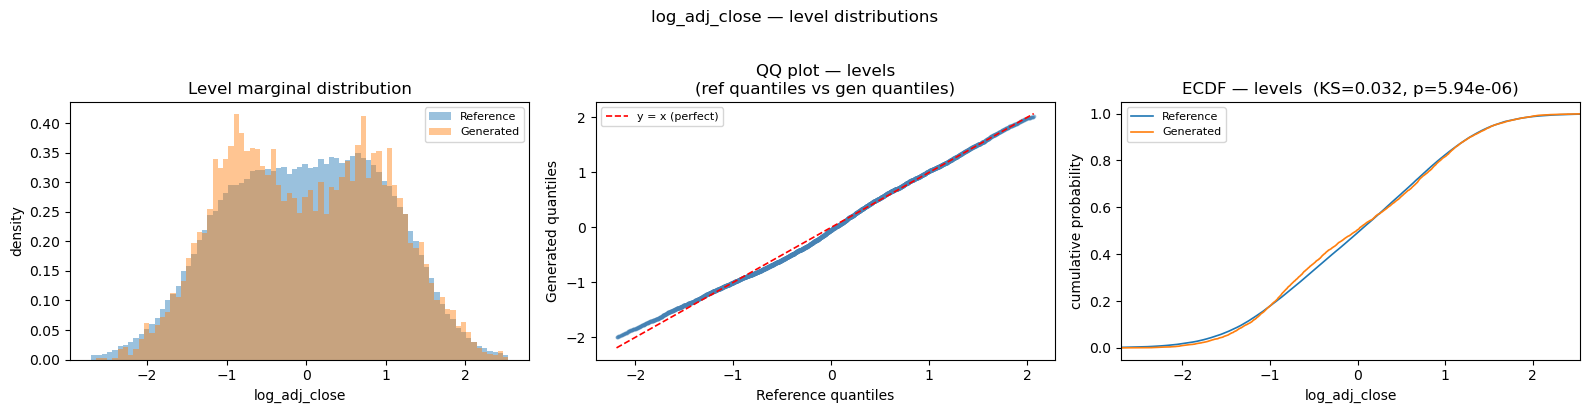

In [7]:
ref_flat = np.concatenate(ref_paths)
gen_flat = np.concatenate(gen_paths)

ks_stat_lev, ks_p_lev = scipy_stats.ks_2samp(ref_flat, gen_flat)
print(f"Levels KS statistic = {ks_stat_lev:.4f}  |  p-value = {ks_p_lev:.4e}")

combined = np.concatenate([ref_flat, gen_flat])
lo, hi   = np.quantile(combined, [0.002, 0.998])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_flat, bins=bins, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Level marginal distribution")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot (ref quantiles vs gen quantiles)
ax = axes[1]
n_q  = min(len(ref_flat), len(gen_flat), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref = np.quantile(ref_flat, probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — levels\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_flat, "Reference", "tab:blue"),
    (gen_flat, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF — levels  (KS={ks_stat_lev:.3f}, p={ks_p_lev:.2e})")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("log_adj_close — level distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4. Increment distribution: histogram, QQ plot, ECDF

Increments KS statistic = 0.0852  |  p-value = 3.0195e-38


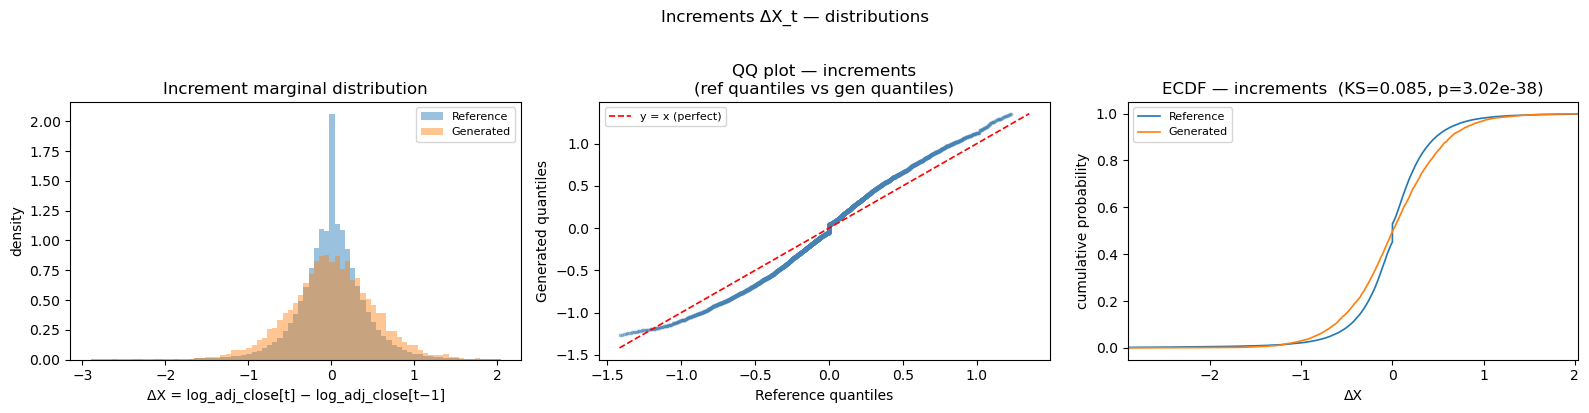

In [8]:
ref_incs = np.concatenate([np.diff(p) for p in ref_paths if len(p) > 1])
gen_incs = np.concatenate([np.diff(p) for p in gen_paths if len(p) > 1])

ks_stat_inc, ks_p_inc = scipy_stats.ks_2samp(ref_incs, gen_incs)
print(f"Increments KS statistic = {ks_stat_inc:.4f}  |  p-value = {ks_p_inc:.4e}")

combined_inc = np.concatenate([ref_incs, gen_incs])
lo_i, hi_i  = np.quantile(combined_inc, [0.002, 0.998])
bins_i      = np.linspace(lo_i, hi_i, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_incs, bins=bins_i, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_incs, bins=bins_i, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Increment marginal distribution")
ax.set_xlabel("ΔX = log_adj_close[t] − log_adj_close[t−1]")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot
ax = axes[1]
n_q  = min(len(ref_incs), len(gen_incs), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref_i = np.quantile(ref_incs, probs)
q_gen_i = np.quantile(gen_incs, probs)
ax.scatter(q_ref_i, q_gen_i, s=3, alpha=0.4, color="steelblue")
lims_i = [min(q_ref_i.min(), q_gen_i.min()), max(q_ref_i.max(), q_gen_i.max())]
ax.plot(lims_i, lims_i, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_incs, "Reference", "tab:blue"),
    (gen_incs, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo_i, hi_i)
ax.set_title(f"ECDF — increments  (KS={ks_stat_inc:.3f}, p={ks_p_inc:.2e})")
ax.set_xlabel("ΔX")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("Increments ΔX_t — distributions", y=1.02)
plt.tight_layout()
plt.show()

## 5. Sample paths

Visual check: do the shapes, scale, and fan-out look alike?

Reference paths may be longer; if so, a random window of the generated-path length is
extracted (using `SEED`) for a fair apples-to-apples visual.

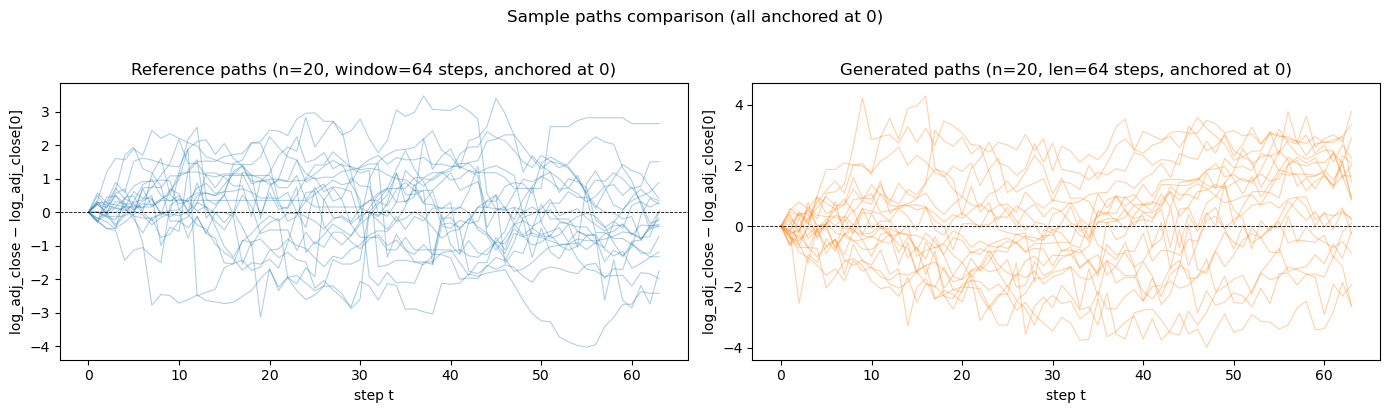

In [9]:
N_SHOW   = 20
GEN_LEN  = int(np.median(gen_lens))   # typical generated path length

# Sample random paths from each dataset
ref_idx = rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    """Extract a random window of `window_len` from `path`."""
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for i in ref_idx:
    p = extract_window(ref_paths[i], GEN_LEN, rng)
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={len(ref_idx)}, window={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

# Generated
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i]
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:orange")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={len(gen_idx)}, len={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

plt.suptitle("Sample paths comparison (all anchored at 0)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Autocorrelation: levels vs increments

**Rationale**:
- *Levels*: log-price paths should show high persistence (ACF ≈ 1, slow decay).
- *Increments*: log-returns should be nearly i.i.d. (ACF ≈ 0 at all lags ≥ 1).

We average ACFs across multiple paths for a stable estimate.  
For reference paths longer than `GEN_LEN` we extract the first `GEN_LEN` steps.

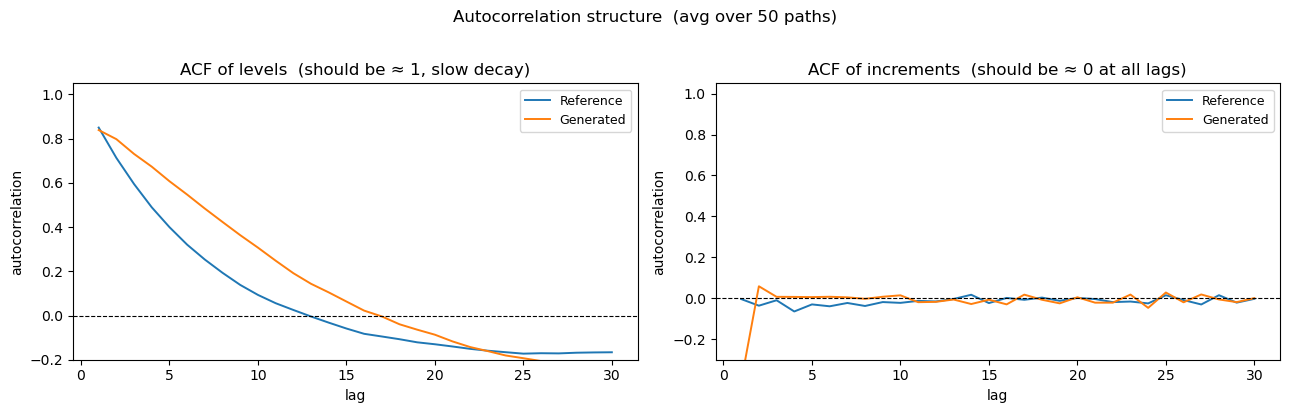

Ref  level  ACF at lag-1: 0.850  |  Gen  level  ACF at lag-1: 0.839
Ref  inc    ACF at lag-1: -0.004  |  Gen  inc    ACF at lag-1: -0.407


In [10]:
N_ACF_PATHS = min(50, len(ref_paths), len(gen_paths))
LAGS        = min(30, GEN_LEN // 2)

def mean_acf_across_paths(
    paths: list[np.ndarray],
    n_paths: int,
    lags: int,
    use_diff: bool = False,
    max_len: int | None = None,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Average ACF (lags 1..lags) across up to `n_paths` paths."""
    indices = (
        rng.choice(len(paths), size=n_paths, replace=False)
        if rng is not None
        else np.arange(min(n_paths, len(paths)))
    )
    acfs = []
    for i in indices:
        x = paths[i]
        if max_len is not None and len(x) > max_len:
            x = x[:max_len]   # align to generated path length
        if use_diff:
            x = np.diff(x)
        if len(x) <= lags:
            continue
        acfs.append(sm_acf(x, nlags=lags, fft=True)[1:])   # skip lag-0 (=1)
    return np.mean(acfs, axis=0) if acfs else np.zeros(lags)

lag_axis = np.arange(1, LAGS + 1)

ref_acf_lev = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
                                    use_diff=False, max_len=GEN_LEN, rng=rng)
gen_acf_lev = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
                                    use_diff=False, max_len=None, rng=rng)
ref_acf_inc = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
                                    use_diff=True,  max_len=GEN_LEN, rng=rng)
gen_acf_inc = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
                                    use_diff=True,  max_len=None, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(lag_axis, ref_acf_lev, label="Reference", color="tab:blue",   linewidth=1.4)
ax.plot(lag_axis, gen_acf_lev, label="Generated", color="tab:orange", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of levels  (should be ≈ 1, slow decay)")
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.2, 1.05)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(lag_axis, ref_acf_inc, label="Reference", color="tab:blue",   linewidth=1.4)
ax.plot(lag_axis, gen_acf_inc, label="Generated", color="tab:orange", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of increments  (should be ≈ 0 at all lags)")
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.3, 1.05)
ax.legend(fontsize=9)

plt.suptitle(f"Autocorrelation structure  (avg over {N_ACF_PATHS} paths)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Ref  level  ACF at lag-1: {ref_acf_lev[0]:.3f}  |  "
      f"Gen  level  ACF at lag-1: {gen_acf_lev[0]:.3f}")
print(f"Ref  inc    ACF at lag-1: {ref_acf_inc[0]:.3f}  |  "
      f"Gen  inc    ACF at lag-1: {gen_acf_inc[0]:.3f}")

## 7. Interpretation guide

| Test | Passing | Failing |
|------|---------|--------|
| **Level KS** (§3) | p > 0.05; QQ on diagonal | S-curve in QQ; large KS stat |
| **Increment KS** (§4) | p > 0.05; QQ on diagonal | Tail mismatch (fat tails not reproduced) |
| **Sample paths** (§5) | Similar scale, fan-out, no collapse | Paths cluster / diverge / show periodicity |
| **Level ACF** (§6) | High persistence (ACF ≈ 1, slow decay) | Geometric decay → AR-like collapse |
| **Increment ACF** (§6) | ACF ≈ 0 at all lags ≥ 1 | Positive ACF → spurious momentum |

**Note on fat tails**: real log-returns have excess kurtosis > 0.  
A model that reproduces the increment std but not the kurtosis has learned the scale but
not the tail structure — visible as an S-curve on the increment QQ plot.